загрузка цены и дельты

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRICING_SUMMARY = "../output/summary/pricing_A_base_summary.csv"
GREEKS_RAW = "../output/metrics_draft/heston.csv"

pricing = pd.read_csv(PRICING_SUMMARY)
greeks = pd.read_csv(GREEKS_RAW)

# фильтруем нужный сценарий (если в summary больше одного)
def pick_base(df):
    cols = [c for c in ["model","payoff","spot","strike","maturity","volatility","drift","dividend","nb_stocks","nb_dates","nb_paths"] if c in df.columns]
    if not cols: return df.copy()
    sc = df[cols].drop_duplicates().iloc[0].to_dict()
    m = np.ones(len(df), dtype=bool)
    for k,v in sc.items():
        m &= (df[k]==v)
    return df.loc[m].copy()

pricing1 = pick_base(pricing)

# из pricing берём V0
V0 = pricing1.set_index("algo")["price_mean"].to_dict()

# из greeks берём delta (для каждого algo должна быть строка с spot=S0)
# при необходимости также ограничьте по payoff/model/params
delta0_df = greeks.dropna(subset=["delta"]).copy()
delta0 = delta0_df.set_index("algo")["delta"].to_dict()

V0, delta0


({'LSM': 6.040004855386485,
  'NLSM': 6.0045400084967,
  'RLSM': 5.720469244342183},
 {'LSM': -0.4232066590603929,
  'RLSM': -0.4169380267397949,
  'NLSM': -0.4178523957477043})

симуляция BS траекторий (out-of-sample)

In [4]:
def simulate_bs_paths(S0, r, q, sigma, T, n_steps, n_paths, seed=123):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal((n_paths, n_steps))
    S = np.empty((n_paths, n_steps+1))
    S[:,0] = S0
    drift = (r - q - 0.5*sigma**2)*dt
    vol = sigma*np.sqrt(dt)
    for t in range(1, n_steps+1):
        S[:,t] = S[:,t-1]*np.exp(drift + vol*Z[:,t-1])
    return S, dt

# параметры — возьмите из base сценария
S0 = 100
K = 100
r = 0.05
q = 0.0
sigma = 0.2
T = 1.0
n_steps = 50

S_paths, dt = simulate_bs_paths(S0, r, q, sigma, T, n_steps, n_paths=50000, seed=1)
S_paths.shape


(50000, 51)

хедж (buy-and-hold delta0) и shortfall L

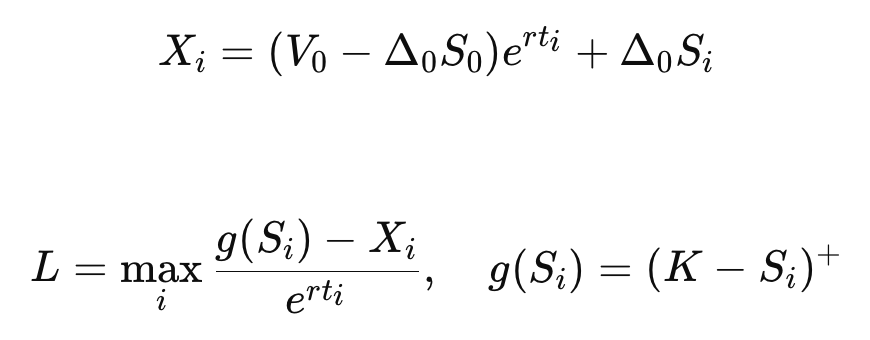

In [5]:
def payoff_put(S, K):
    return np.maximum(K - S, 0.0)

def hedging_shortfall_buyhold(S_paths, V0, delta0, r, dt, K):
    n_paths, n_steps_plus1 = S_paths.shape
    n_steps = n_steps_plus1 - 1
    t = np.arange(0, n_steps_plus1) * dt
    disc = np.exp(r*t)

    S0 = S_paths[:,0]
    # капитал по времени (buy&hold)
    # X_i = (V0 - delta0*S0)*e^{r t_i} + delta0*S_i
    X = (V0 - delta0*S0)[:,None]*disc[None,:] + delta0*S_paths

    g = payoff_put(S_paths, K)
    # shortfall discounted: (g - X)/e^{r t}
    shortfall = (g - X) / disc[None,:]
    # интересует максимум по i=1..n (можно исключить 0)
    L = np.max(shortfall[:,1:], axis=1)
    return L

results = {}
for algo in ["LSM","RLSM","NLSM"]:
    if algo in V0 and algo in delta0:
        L = hedging_shortfall_buyhold(S_paths, V0[algo], delta0[algo], r, dt, K)
        results[algo] = L

{k: (v.mean(), np.quantile(v, 0.95)) for k,v in results.items()}


{'LSM': (3.9408883625566498, 13.348308361884738),
 'RLSM': (4.244613933551901, 13.545671559631842),
 'NLSM': (3.962797813551522, 13.282275257590896)}

графики распределения + VaR/CVaR + маржа

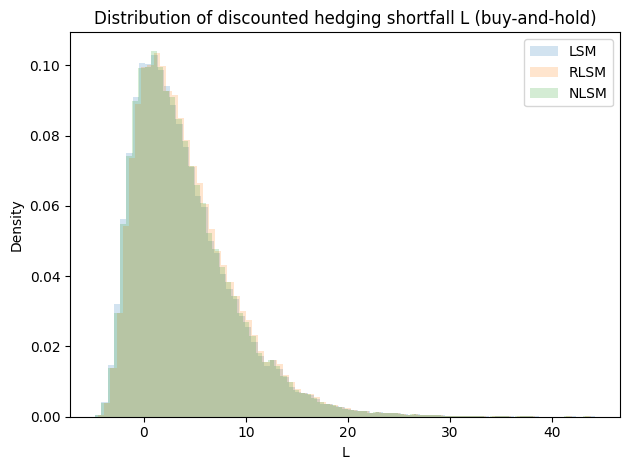

,algo,V0_price_mean,delta0,VaR_0.99,CVaR_0.99,recommended_margin_0.99,recommended_sell_price_0.99
0,LSM,6.040005,-0.423207,20.379301,24.939824,20.379301,26.419306
2,NLSM,6.004540,-0.417852,20.098493,24.591376,20.098493,26.103033
1,RLSM,5.720469,-0.416938,20.325443,24.810260,20.325443,26.045912


In [8]:
def var_cvar(x, alpha=0.99):
    q = np.quantile(x, alpha)
    tail = x[x >= q]
    cvar = tail.mean() if len(tail) else np.nan
    return q, cvar

alpha = 0.99

summary_rows = []
plt.figure()
for algo, L in results.items():
    # гистограмма (можно заменить на ECDF)
    plt.hist(L, bins=80, density=True, alpha=0.2, label=algo)

    VaR, CVaR = var_cvar(L, alpha=alpha)
    summary_rows.append({
        "algo": algo,
        "V0_price_mean": V0[algo],
        "delta0": delta0[algo],
        f"VaR_{alpha}": VaR,
        f"CVaR_{alpha}": CVaR,
        f"recommended_margin_{alpha}": VaR,  # базово: маржа = VaR
        f"recommended_sell_price_{alpha}": V0[algo] + VaR
    })

plt.title("Distribution of discounted hedging shortfall L (buy-and-hold)")
plt.xlabel("L")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

hedge_table = pd.DataFrame(summary_rows).sort_values("algo")
hedge_table


* распределения практически совпадают;
* есть правый хвост (редкие плохие сценарии), но он похож для всех методов

* алгоритмы дают близкие $V_0$  и близкую $\delta_0$ $\Rightarrow$ при buy-and-hold хедже результат неизбежно схож.
* метод хеджа (buy-and-hold) настолько грубый, что доминирует над тонкой разницей между алгоритмами.

In [ ]:
os.makedirs("output/analysis", exist_ok=True)
hedge_table.to_csv("output/analysis/hedging_risk_buyhold_summary.csv", index=False)
